# Optimización de Hiperparámetros

Tuneo sistemático de los 4 modelos del notebook anterior: Decision Tree, Random Forest, XGBoost y KNN.

## Decisiones de diseño

**Método: `RandomizedSearchCV` (no `GridSearchCV`)**  
Con distribuciones continuas (ej. `learning_rate`) GridSearch es inviable. RandomizedSearch cubre mejor el espacio de búsqueda con menos iteraciones.

**Métrica objetivo: F2-score (Fbeta con beta=2)**  
- `Recall` puro es peligroso: el optimizador puede elegir modelos que predicen 'stroke' para casi todos (Recall≈1, Precision≈0).
- `F1` da igual peso a Precision y Recall — no refleja que un falso negativo es mucho peor que un falso positivo.
- **F2 pesa Recall ~4× más que Precision**. Es el estándar en problemas médicos con clases desbalanceadas.

**Manejo del desbalance: `class_weight` (consistente con notebook 02)**  
Para sklearn usamos `class_weight='balanced'`; para XGBoost `scale_pos_weight = n_negativos / n_positivos`. No se usan pipelines, los parámetros se pasan directamente al clasificador.

**CV: StratifiedKFold 5-fold (idéntico al notebook 02)** para que la comparación baseline vs tuneado sea justa.


In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    make_scorer, fbeta_score,
    roc_auc_score, average_precision_score, f1_score,
    recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)
import warnings
warnings.filterwarnings('ignore')

# Cargar datos preprocesados (mismo pkl que notebook 02)
data = joblib.load("../data/processed_data.pkl")
X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Distribución de clases (train): {np.bincount(y_train.astype(int))}")

X_train: (3576, 14), X_test: (1533, 14)
Distribución de clases (train): [3402  174]


## Setup compartido: scorer F2 y CV

Definimos el scorer una sola vez y lo reutilizamos en los 3 `RandomizedSearchCV`.

In [2]:
# Scorer F2: pesa Recall ~4× Precision (beta=2)
f2_scorer = make_scorer(fbeta_score, beta=2)

# CV estratificada idéntica al notebook 02
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scale_pos_weight para XGBoost: razón clases negativas / positivas
neg, pos = np.bincount(y_train)
scale_pos = neg / pos

# Parámetros comunes para los RandomizedSearchCV
search_kwargs = dict(
    n_iter=30,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,
    return_train_score=False,
)

tuning_results = {}
tuned_models   = {}


## Decision Tree

Explorar profundidad, criterio de split y regularización (`min_samples_*`). Se usa `class_weight='balanced'` para manejar el desbalance.


In [3]:
name = "Decision Tree"

dt_param_dist = {
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_leaf':  randint(1, 50),
    'min_samples_split': randint(2, 20),
    'criterion':         ['gini', 'entropy'],
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_distributions=dt_param_dist,
    **search_kwargs,
)
dt_search.fit(X_train, y_train)

tuning_results[name] = {
    'best_params': dt_search.best_params_,
    'best_f2_cv':  dt_search.best_score_,
    'cv_results':  dt_search.cv_results_,
}
tuned_models[name] = dt_search.best_estimator_

print(f"Mejores parámetros ({name}):")
for k, v in dt_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F2 en CV: {dt_search.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros (Decision Tree):
  criterion: gini
  max_depth: 15
  min_samples_leaf: 36
  min_samples_split: 9

Mejor F2 en CV: 0.3968


## Random Forest

Explorar número de árboles, profundidad y muestreo de features. Se usa `class_weight='balanced'`.


In [4]:
name = "Random Forest"

rf_param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [5, 10, 15, 20, None],
    'min_samples_leaf': randint(1, 20),
    'max_features':     ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    **search_kwargs,
)
rf_search.fit(X_train, y_train)

tuning_results[name] = {
    'best_params': rf_search.best_params_,
    'best_f2_cv':  rf_search.best_score_,
    'cv_results':  rf_search.cv_results_,
}
tuned_models[name] = rf_search.best_estimator_

print(f"Mejores parámetros ({name}):")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F2 en CV: {rf_search.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros (Random Forest):
  max_depth: 5
  max_features: 0.5
  min_samples_leaf: 11
  n_estimators: 300

Mejor F2 en CV: 0.4019


## XGBoost

El espacio más rico: learning rate, subsampling de filas y columnas. Se usa `scale_pos_weight` para manejar el desbalance.


In [5]:
name = "XGBoost"

xgb_param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        randint(3, 10),
    'learning_rate':    uniform(0.01, 0.29),
    'min_child_weight': randint(1, 10),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos,
        eval_metric='aucpr',
        random_state=42,
        use_label_encoder=False,
        n_jobs=1,
    ),
    param_distributions=xgb_param_dist,
    **search_kwargs,
)
xgb_search.fit(X_train, y_train)

tuning_results[name] = {
    'best_params': xgb_search.best_params_,
    'best_f2_cv':  xgb_search.best_score_,
    'cv_results':  xgb_search.cv_results_,
}
tuned_models[name] = xgb_search.best_estimator_

print(f"Mejores parámetros ({name}):")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F2 en CV: {xgb_search.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros (XGBoost):
  colsample_bytree: 0.7988994023569542
  learning_rate: 0.09725470984686319
  max_depth: 3
  min_child_weight: 8
  n_estimators: 100
  subsample: 0.706712405710114

Mejor F2 en CV: 0.3974


## KNN

Explorar cantidad de vecinos, tipo de peso y métrica de distancia. `p=1` es distancia Manhattan, `p=2` es Euclidiana. KNN no soporta `class_weight`, por lo que el desbalance no se corrige en este modelo.


In [6]:
name = "KNN"

knn_param_dist = {
    'n_neighbors': randint(3, 30),
    'weights':     ['uniform', 'distance'],
    'p':           [1, 2],
}

knn_search = RandomizedSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_distributions=knn_param_dist,
    **search_kwargs,
)
knn_search.fit(X_train, y_train)

tuning_results[name] = {
    'best_params': knn_search.best_params_,
    'best_f2_cv':  knn_search.best_score_,
    'cv_results':  knn_search.cv_results_,
}
tuned_models[name] = knn_search.best_estimator_

print(f"Mejores parámetros ({name}):")
for k, v in knn_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F2 en CV: {knn_search.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros (KNN):
  n_neighbors: 4
  p: 2
  weights: distance

Mejor F2 en CV: 0.0587


## Optimizacion con Optuna

In [11]:
import optuna
from sklearn.model_selection import cross_val_score
beta = 2
ftwo_scorer = make_scorer(fbeta_score, beta=beta)

def objective_decision_tree_classifier(trial):
    max_depth = trial.suggest_int("max_depth", 5, 30)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    classifier = DecisionTreeClassifier(criterion=criterion, splitter='best', class_weight=class_weight,
                                        max_depth=max_depth, min_samples_split=min_samples_split, 
                                        min_samples_leaf=min_samples_leaf, random_state=42)
    
    # Realizamos la validación cruzada
    score = cross_val_score(classifier, X_train, y_train, cv=10, scoring=ftwo_scorer, n_jobs=-1)
    
    return score.mean()

In [16]:
def objective_random_forest_classifier(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 5, 30)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ['sqrt', 'log2', 0.5])
    class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    classifier = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features=max_features,
                                        class_weight=class_weight, criterion=criterion, random_state=42)
    
    # Realizamos la validación cruzada
    score = cross_val_score(classifier, X_train, y_train, cv=10, scoring=ftwo_scorer, n_jobs=-1)
    
    return score.mean()

In [9]:
def champion_callback(study, frozen_trial):
    """
    Mostramos menos información, sino es demasiado verboso
    """
    winner = study.user_attrs.get("winner", None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} with "
                f"{improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value}")

In [12]:
# Creamos un estudio de Optuna
# Optuna es un poco verboso, dejamos que solo nos muestre logs de errores
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(direction="maximize")
study.optimize(objective_decision_tree_classifier, n_trials=1000, callbacks=[champion_callback])
# Obtenemos los mejores hiperparámetros encontrados
best_params_decision_tree_classifier = study.best_params
best_params_decision_tree_classifier

Initial trial 0 achieved value: 0.21964937771689041
Trial 1 achieved value: 0.3257658197092733 with  32.5745% improvement
Trial 10 achieved value: 0.3263513876409912 with  0.1794% improvement
Trial 15 achieved value: 0.36108264789661376 with  9.6186% improvement
Trial 22 achieved value: 0.3646965629302356 with  0.9909% improvement
Trial 60 achieved value: 0.3650327855128965 with  0.0921% improvement
Trial 65 achieved value: 0.3654367697402182 with  0.1105% improvement


{'max_depth': 5,
 'criterion': 'entropy',
 'class_weight': 'balanced',
 'min_samples_split': 13,
 'min_samples_leaf': 13}

In [17]:
study = optuna.create_study(direction="maximize")
study.optimize(objective_random_forest_classifier, n_trials=100, callbacks=[champion_callback])
# Obtenemos los mejores hiperparámetros encontrados
best_params_random_forest_classifier = study.best_params
best_params_random_forest_classifier

Initial trial 5 achieved value: 0.40167166457494563
Trial 25 achieved value: 0.40179451981837266 with  0.0306% improvement
Trial 26 achieved value: 0.40229938062511283 with  0.1255% improvement
Trial 45 achieved value: 0.4030624387008651 with  0.1893% improvement
Trial 52 achieved value: 0.4079604385245674 with  1.2006% improvement
Trial 87 achieved value: 0.4085840886200408 with  0.1526% improvement
Trial 91 achieved value: 0.4103151388262597 with  0.4219% improvement


{'n_estimators': 206,
 'max_depth': 28,
 'min_samples_leaf': 19,
 'max_features': 'sqrt',
 'class_weight': 'balanced',
 'criterion': 'entropy'}

In [21]:
decision_tree_classifier_op = DecisionTreeClassifier(**best_params_decision_tree_classifier, random_state=42)
decision_tree_classifier_op.fit(X_train, y_train)
tuned_models['decision_tree_classifier_op'] = decision_tree_classifier_op
random_forest_classifier_op = RandomForestClassifier(**best_params_random_forest_classifier, random_state=42)
random_forest_classifier_op.fit(X_train, y_train)
tuned_models['random_forest_classifier_op'] = random_forest_classifier_op

## Comparación: baseline vs tuneado

Cargamos los resultados del notebook 02 y calculamos la ganancia en F2 conseguida por el tuneo.

In [ ]:
# Calcular F2 baseline a partir de los resultados del notebook 02
baseline = joblib.load('../data/training_results.pkl')
baseline_cv = baseline['cv_results']

# F2 = (1+4) * P*R / (4*P + R) -> lo reconstruimos a partir de Precision y Recall por fold
def f2_from_pr(precision_arr, recall_arr):
    beta2 = 4
    f2 = np.where(
        (beta2 * precision_arr + recall_arr) > 0,
        (1 + beta2) * precision_arr * recall_arr / (beta2 * precision_arr + recall_arr),
        0.0,
    )
    return f2

rows = []
for model_name in ['Decision Tree', 'Random Forest', 'XGBoost', 'KNN']:
    if model_name in baseline_cv:
        base_f2 = f2_from_pr(baseline_cv[model_name]['Precision'], baseline_cv[model_name]['Recall']).mean()
    else:
        base_f2 = np.nan
    tuned_f2 = tuning_results[model_name]['best_f2_cv']
    rows.append({
        'Modelo':          model_name,
        'F2 Baseline (CV)': f"{base_f2:.4f}",
        'F2 Tuneado (CV)':  f"{tuned_f2:.4f}",
        'Ganancia':         f"{tuned_f2 - base_f2:+.4f}",
    })

comparison_df = pd.DataFrame(rows).set_index('Modelo')
display(comparison_df)

,F2 Baseline (CV),F2 Tuneado (CV),Ganancia
Modelo,,,
Decision Tree,0.3012,0.3968,+0.0956
Random Forest,0.2638,0.4019,+0.1381
XGBoost,0.2684,0.3974,+0.1290
KNN,0.0333,0.0587,+0.0254


## Evaluación en Test Set

Los 4 modelos tuneados ya están reentrenados sobre todo `X_train` (por `refit=True`). Los evaluamos sobre `X_test` con la misma batería de métricas del notebook 02, agregando F2.

In [22]:
test_rows = []
for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    test_rows.append({
        'Modelo':    name,
        'AUC-ROC':   roc_auc_score(y_test, y_prob),
        'PR-AUC':    average_precision_score(y_test, y_prob),
        'F1':        f1_score(y_test, y_pred),
        'F2':        fbeta_score(y_test, y_pred, beta=2),
        'Recall':    recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
    })

test_df = pd.DataFrame(test_rows).set_index('Modelo')
display(test_df.sort_values('F2', ascending=False).style.highlight_max(axis=0))

best_tuned_name = test_df['F2'].idxmax()
print(f"\nMejor modelo tuneado por F2: {best_tuned_name} ({test_df.loc[best_tuned_name, 'F2']:.4f})")

,AUC-ROC,PR-AUC,F1,F2,Recall,Precision
Modelo,,,,,,
random_forest_classifier_op,0.825697,0.198199,0.263789,0.428349,0.733333,0.160819
Decision Tree,0.795505,0.190325,0.228814,0.387374,0.720000,0.136020
XGBoost,0.820558,0.203187,0.228448,0.384615,0.706667,0.136247
decision_tree_classifier_op,0.776584,0.143638,0.214008,0.372124,0.733333,0.125285
Random Forest,0.825633,0.232518,0.209924,0.367156,0.733333,0.122494
KNN,0.594691,0.067666,0.055046,0.044910,0.040000,0.088235



Mejor modelo tuneado por F2: random_forest_classifier_op (0.4283)


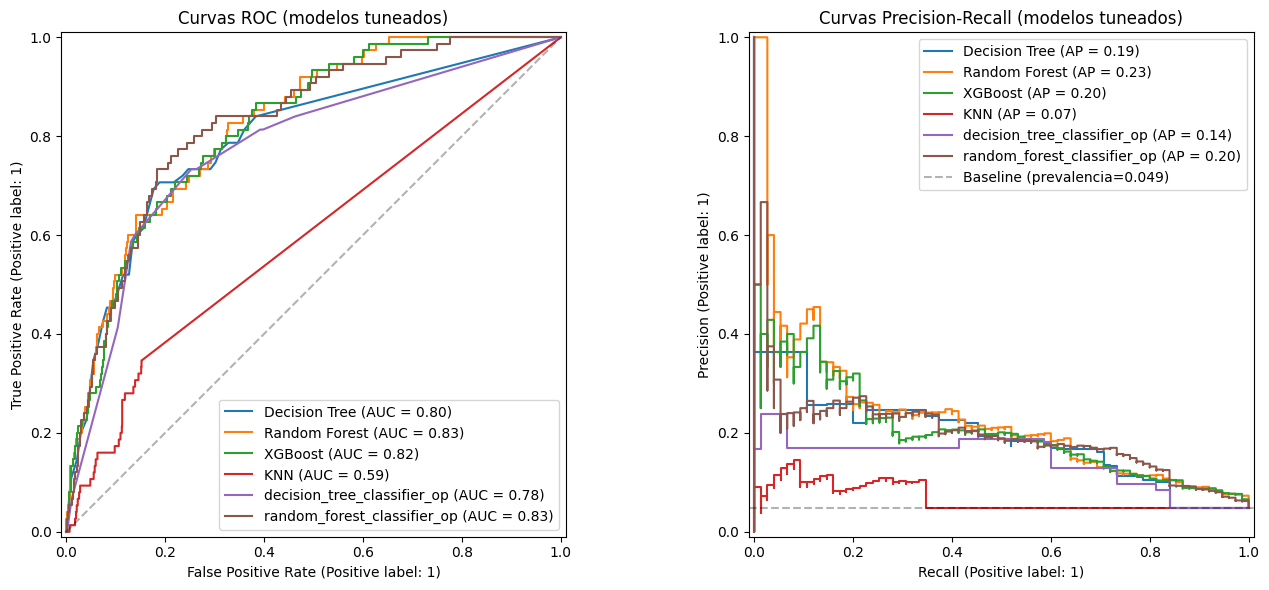

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[1])

axes[0].set_title("Curvas ROC (modelos tuneados)")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)

axes[1].set_title("Curvas Precision-Recall (modelos tuneados)")
prevalence = y_test.mean() if hasattr(y_test, 'mean') else np.mean(y_test)
axes[1].axhline(prevalence, color='k', linestyle='--', alpha=0.3,
                label=f'Baseline (prevalencia={prevalence:.3f})')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

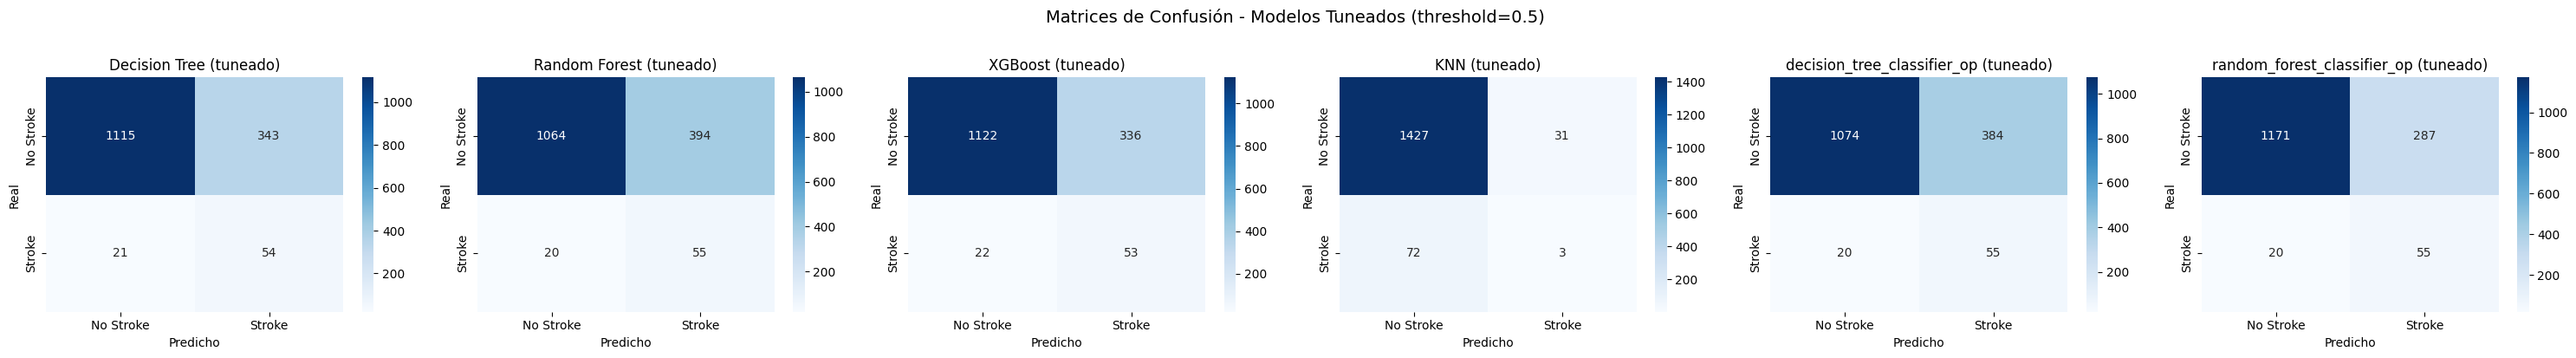

In [24]:
fig, axes = plt.subplots(1, len(tuned_models), figsize=(5 * len(tuned_models), 4))

for i, (name, model) in enumerate(tuned_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    axes[i].set_title(f"{name} (tuneado)")
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

plt.suptitle('Matrices de Confusión - Modelos Tuneados (threshold=0.5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Persistencia

Guardamos los 4 modelos tuneados y un diccionario con `best_params`, métricas CV y métricas de test para que `04_model_evaluation.ipynb` los consuma.

In [25]:
import os
os.makedirs('../models', exist_ok=True)

for name, model in tuned_models.items():
    filename = name.lower().replace(' ', '_') + '_tuned.pkl'
    path = f'../models/{filename}'
    joblib.dump(model, path)
    print(f"Guardado: {path}")

feature_names = list(X_train.columns) if hasattr(X_train, 'columns') else None

joblib.dump({
    'best_params':     {n: r['best_params'] for n, r in tuning_results.items()},
    'cv_best_f2':      {n: r['best_f2_cv']  for n, r in tuning_results.items()},
    'test_results':    test_df,
    'best_model_name': best_tuned_name,
    'feature_names':   feature_names,
}, '../data/tuning_results.pkl')

print("\nResultados guardados en ../data/tuning_results.pkl")
print(f"Mejor modelo tuneado (por F2 en test): {best_tuned_name} -> F2 = {test_df.loc[best_tuned_name, 'F2']:.4f}")

Guardado: ../models/decision_tree_tuned.pkl
Guardado: ../models/random_forest_tuned.pkl
Guardado: ../models/xgboost_tuned.pkl
Guardado: ../models/knn_tuned.pkl
Guardado: ../models/decision_tree_classifier_op_tuned.pkl
Guardado: ../models/random_forest_classifier_op_tuned.pkl

Resultados guardados en ../data/tuning_results.pkl
Mejor modelo tuneado (por F2 en test): random_forest_classifier_op -> F2 = 0.4283
